In [4]:
import os
import subprocess

import pandas as pd
import pyBigWig
from IPython.display import Image

In [5]:
NOTEBOOK_DIR = os.getcwd()
REPO_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))

RESULTS = os.path.join(REPO_ROOT, "results")
MY_BIGWIG = os.path.join(RESULTS, "pseudobulk", "bigwig")
AUTHORS_BIGWIG = os.path.join(RESULTS, "authors_bigwig")
COMPARISON = os.path.join(RESULTS, "comparison")
os.makedirs(AUTHORS_BIGWIG, exist_ok=True)
os.makedirs(COMPARISON, exist_ok=True)

# Cell types with a one-to-one correspondence between this reproduction and
# the published tracks. Neuronal types are excluded: the published tracks
# are split by cortical layer and interneuron subtype, while this analysis
# treats excitatory and inhibitory neurons as single classes.
CELL_TYPE_PAIRS = {
    "Microglia": "Micro_PVM",
    "Astrocytes": "Astro",
    "Oligodendrocytes": "Oligo",
    "OPC": "OPC",
    "Endothelial": "Endo_VLMC",
}

AUTHORS_BASE_URL = (
    "https://ucsctracks.aertslab.org/papers/hydrop_v2_paper/mm10/bw/"
    "mouse_cortex_per_scATAC_platform"
)

In [6]:
for their_name in CELL_TYPE_PAIRS.values():
    filename = f"10x_v2___{their_name}.bw"
    dest = os.path.join(AUTHORS_BIGWIG, filename)
    if os.path.exists(dest):
        print(f"{filename} already present, skipping")
        continue
    url = f"{AUTHORS_BASE_URL}/{filename}"
    print(f"Downloading {filename}...")
    subprocess.run(["wget", "-q", "-O", dest, url], check=True)

for f in sorted(os.listdir(AUTHORS_BIGWIG)):
    size_mb = os.path.getsize(os.path.join(AUTHORS_BIGWIG, f)) / 1e6
    print(f"  {f:32s} {size_mb:7.1f} MB")

10x_v2___Micro_PVM.bw already present, skipping
10x_v2___Astro.bw already present, skipping
10x_v2___Oligo.bw already present, skipping
10x_v2___OPC.bw already present, skipping
10x_v2___Endo_VLMC.bw already present, skipping
  10x_v2___Astro.bw                  141.3 MB
  10x_v2___Endo_VLMC.bw               42.8 MB
  10x_v2___Micro_PVM.bw               84.5 MB
  10x_v2___OPC.bw                     88.1 MB
  10x_v2___Oligo.bw                  185.3 MB


In [7]:
# Chromosome naming must match between the two sets of tracks. A mismatch
# does not raise an error in deeptools: it silently drops the affected
# chromosomes, so it is checked explicitly here.
mine = pyBigWig.open(os.path.join(MY_BIGWIG, "Microglia.bw"))
theirs = pyBigWig.open(os.path.join(AUTHORS_BIGWIG, "10x_v2___Micro_PVM.bw"))

mine_chroms = set(mine.chroms().keys())
theirs_chroms = set(theirs.chroms().keys())
shared = mine_chroms & theirs_chroms

mine.close()
theirs.close()

main_chroms = sorted(c for c in shared if "_" not in c)
print(f"This reproduction: {len(mine_chroms)} contigs")
print(f"Published tracks:  {len(theirs_chroms)} contigs")
print(f"Shared:            {len(shared)} contigs")
print(f"\nShared main chromosomes ({len(main_chroms)}):")
print(main_chroms)

assert len(main_chroms) >= 20, "Too few shared main chromosomes"

This reproduction: 66 contigs
Published tracks:  66 contigs
Shared:            22 contigs

Shared main chromosomes (22):
['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9', 'chrM', 'chrX', 'chrY']


In [8]:
labels_mine = [f"MIO_{ct}" for ct in CELL_TYPE_PAIRS]
labels_theirs = [f"AUT_{ct}" for ct in CELL_TYPE_PAIRS]

files_mine = [os.path.join(MY_BIGWIG, f"{ct}.bw") for ct in CELL_TYPE_PAIRS]
files_theirs = [
    os.path.join(AUTHORS_BIGWIG, f"10x_v2___{their}.bw")
    for their in CELL_TYPE_PAIRS.values()
]

matrix_path = os.path.join(COMPARISON, "matrix.npz")

cmd = [
    "multiBigwigSummary", "bins",
    "-b", *files_mine, *files_theirs,
    "--labels", *labels_mine, *labels_theirs,
    "--binSize", "5000",
    "-p", "8",
    "-o", matrix_path,
]

print("Running multiBigwigSummary (this takes several minutes)...")
result = subprocess.run(cmd, capture_output=True, text=True)
print(f"Exit code: {result.returncode}")
if result.returncode != 0:
    print(result.stderr[-2000:])
else:
    print(f"Matrix written to {matrix_path}")

Running multiBigwigSummary (this takes several minutes)...
Exit code: 0
Matrix written to /home/jovyan/work/repo/results/comparison/matrix.npz


Exit code: 0


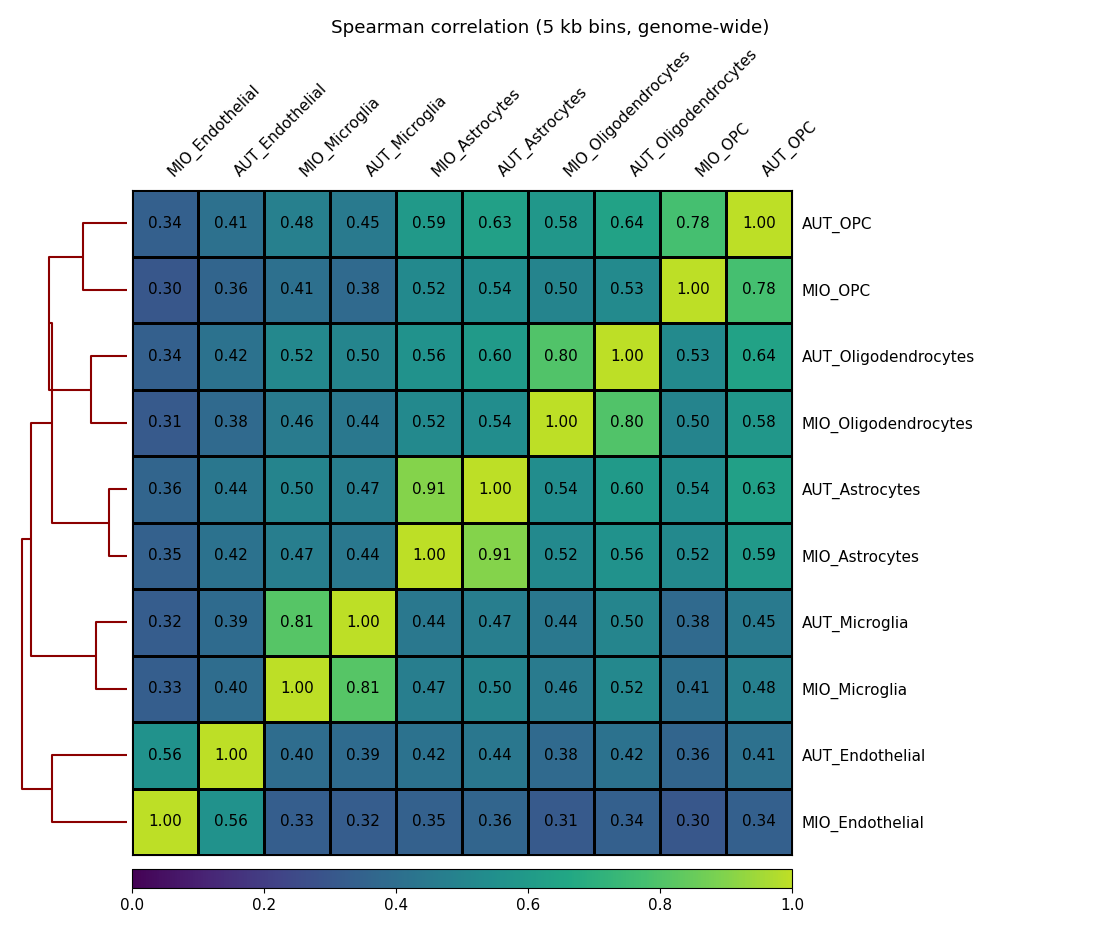

In [9]:
heatmap_path = os.path.join(COMPARISON, "correlation_heatmap.png")
cormatrix_path = os.path.join(COMPARISON, "correlation_matrix.tsv")

cmd = [
    "plotCorrelation",
    "-in", matrix_path,
    "--corMethod", "spearman",
    "--whatToPlot", "heatmap",
    "--plotNumbers",
    "--skipZeros",
    "--colorMap", "viridis",
    "--plotTitle", "Spearman correlation (5 kb bins, genome-wide)",
    "-o", heatmap_path,
    "--outFileCorMatrix", cormatrix_path,
]

result = subprocess.run(cmd, capture_output=True, text=True)
print(f"Exit code: {result.returncode}")
if result.returncode != 0:
    print(result.stderr[-2000:])

Image(heatmap_path)

In [10]:
cormat = pd.read_csv(cormatrix_path, sep="\t", skiprows=1, index_col=0)
cormat.index = [i.strip("'") for i in cormat.index]
cormat.columns = [c.strip("'") for c in cormat.columns]

print("Spearman correlation between matched cell types")
print("-" * 60)
for ct in CELL_TYPE_PAIRS:
    mine_label, theirs_label = f"MIO_{ct}", f"AUT_{ct}"
    homologous = cormat.loc[mine_label, theirs_label]

    # Highest correlation with any non-matching published track, as a
    # measure of specificity
    others = [f"AUT_{o}" for o in CELL_TYPE_PAIRS if o != ct]
    best_other = cormat.loc[mine_label, others].max()
    best_other_name = cormat.loc[mine_label, others].idxmax()

    print(f"{ct:20s} {homologous:.3f}   (next best: {best_other:.3f} with {best_other_name})")

Spearman correlation between matched cell types
------------------------------------------------------------
Microglia            0.815   (next best: 0.516 with AUT_Oligodendrocytes)
Astrocytes           0.905   (next best: 0.594 with AUT_OPC)
Oligodendrocytes     0.802   (next best: 0.583 with AUT_OPC)
OPC                  0.778   (next best: 0.540 with AUT_Astrocytes)
Endothelial          0.565   (next best: 0.361 with AUT_Astrocytes)
